[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/heitorramos/icd/blob/main/exemplos/06-boas-praticas-visualizacao/notebook-colab.ipynb)


In [ ]:
# Preparação automática para execução no Google Colab.
# Fora do Colab, esta célula não altera o diretório de trabalho.
try:
    import google.colab  # type: ignore
except ImportError:
    pass
else:
    import os
    import subprocess
    from pathlib import Path

    repository = Path("/content/icd")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/heitorramos/icd.git", str(repository)
        ], check=True)
    os.chdir(repository / "exemplos/06-boas-praticas-visualizacao")
    print("Material preparado em:", Path.cwd())


# Material de apoio — Boas práticas de visualização

TMDB 5000 Movie Dataset

## Objetivos

Neste notebook, a mesma base será representada de maneiras diferentes. O
objetivo é justificar escolhas de escala, ordem, cor, destaque, contexto
e transformação.

## Como estudar este capítulo

Boas práticas de visualização não são regras decorativas. Escala, ordem,
transformação e cor alteram aquilo que o leitor consegue comparar e
podem mudar a impressão produzida pelos mesmos dados. O critério central
é comunicar a estrutura relevante sem esconder incerteza, contexto ou
limitações.

Usaremos a base TMDB para reconstruir gráficos deliberadamente
problemáticos e comparar versões corrigidas. Em cada par, pergunte: qual
afirmação a primeira versão parece sustentar, qual decisão visual
produziu essa impressão e o que muda na versão revisada? Esse contraste
ajuda a aprender mais do que uma lista de proibições.

O código mostra como implementar as escolhas, mas a parte essencial é a
justificativa. Uma transformação logarítmica, por exemplo, é útil quando
queremos comparar ordens de grandeza; ela não apaga valores extremos nem
torna automaticamente a distribuição “correta”. Um bom gráfico deve
permitir que o leitor reconheça o que foi transformado.

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
movies = pd.read_csv(Path("data") / "tmdb_movies.csv")
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["year"] = movies["release_date"].dt.year
movies["profit"] = movies["revenue"] - movies["budget"]
movies["roi"] = movies["revenue"] / movies["budget"]

def first_genre(value):
    try:
        genres = json.loads(value)
        return genres[0]["name"] if genres else "Sem gênero"
    except Exception:
        return "Sem gênero"

movies["main_genre"] = movies["genres"].map(first_genre)
valid = movies.query("budget > 100000 and revenue > 100000").copy()

olist_orders = pd.read_csv(Path("data") / "olist_orders.csv",
                           parse_dates=["order_purchase_timestamp"])
olist_customers = pd.read_csv(Path("data") / "olist_customers.csv")
olist = olist_orders.merge(olist_customers, on="customer_id", validate="many_to_one")

## O que é a base?

Uma linha representa um filme. A base reúne metadados do TMDB sobre
produção e recepção: título, lançamento, gênero, orçamento, receita,
duração, popularidade, média e quantidade de votos.

In [ ]:
movies.shape, movies[["original_title", "year", "main_genre", "budget", "revenue", "vote_average"]].head()

In [ ]:
movies[["budget", "revenue", "vote_average", "vote_count"]].describe().T

In [ ]:
movies[["budget", "revenue", "runtime", "release_date"]].isna().mean().sort_values(ascending=False)

> **Interpretação**
>
> Antes de interpretar resultados, confirme o que cada linha representa,
> o período coberto e as colunas realmente disponíveis. Essa definição
> determina quais agregações e comparações são válidas.

Valores financeiros iguais a zero devem ser tratados com cautela:
frequentemente significam informação não disponível.

## Ordem e comparação

In [ ]:
top = movies["main_genre"].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
top.plot.bar(ax=axes[0], color="#176b87", title="Ordem de aparição")
top.sort_values().plot.barh(ax=axes[1], color="#176b87", title="Ordem por valor")
plt.tight_layout(); plt.show()

> **Interpretação**
>
> A codificação visual deve reduzir o esforço necessário para responder
> à pergunta. Ordem, contraste e anotação devem destacar a evidência sem
> esconder categorias, incerteza ou contexto.

### Exercício 1

Qual versão permite localizar mais rapidamente o terceiro gênero mais
frequente? Explique usando a ideia de posição e comprimento alinhados.

## Eixo truncado

In [ ]:
small = top.tail(5).sort_values()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
small.plot.barh(ax=axes[0], color="#176b87", title="Zero visível")
small.plot.barh(ax=axes[1], color="#b23b3b", title="Eixo truncado")
axes[1].set_xlim(small.min() * .96, small.max() * 1.01)
plt.tight_layout(); plt.show()

> **Interpretação**
>
> Em barras, o comprimento parte de uma origem; truncar o eixo altera
> visualmente a razão entre categorias. Linhas e pontos podem usar
> domínios locais quando a pergunta é variação, desde que a escala
> esteja explícita.

O segundo painel exagera razões porque exibe apenas a extremidade das
barras.

## Escalas duplas

Quando duas séries usam eixos verticais independentes, a escolha de
orientação e domínio pode fabricar uma impressão de concordância. Nos
painéis abaixo, os dados são idênticos; somente o segundo eixo foi
invertido.

In [ ]:
annual_dual = (movies.query("1980 <= year <= 2016")
               .groupby("year")
               .agg(filmes=("id", "size"), nota=("vote_average", "mean"))
               .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, invert, title in zip(
    axes,
    [False, True],
    ["Eixo usual: curvas se opõem", "Eixo invertido: curvas acompanham"],
):
    ax2 = ax.twinx()
    ax.plot(annual_dual["year"], annual_dual["filmes"], color="#176b87")
    ax2.plot(annual_dual["year"], annual_dual["nota"], color="#d97727")
    if invert:
        ax2.invert_yaxis()
    ax.set_title(title)
    ax.set_ylabel("filmes", color="#176b87")
    ax2.set_ylabel("nota média", color="#d97727")
plt.tight_layout(); plt.show()

Prefira painéis alinhados com escalas declaradas, índices com uma base
comum ou uma dispersão que represente diretamente a relação entre as
variáveis.

## Transformações logarítmicas

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=valid, x="budget", y="revenue", alpha=.3, ax=axes[0])
sns.scatterplot(data=valid, x="budget", y="revenue", alpha=.3, ax=axes[1])
axes[1].set(xscale="log", yscale="log")
axes[0].set_title("Linear"); axes[1].set_title("Log-log")
plt.tight_layout(); plt.show()

> **Interpretação**
>
> O log preserva a ordem, mas transforma razões em distâncias. No
> exemplo didático, a observação de 45 minutos comprime a escala
> original; após o log, a região entre 2 e 5 minutos volta a ficar
> legível.

In [ ]:
valid[["budget", "revenue"]].corr(), np.log10(valid[["budget", "revenue"]]).corr()

### Exercício 2

Adicione a linha `revenue = budget`. Interprete pontos acima e abaixo
dela na escala log-log.

In [ ]:
ax = sns.scatterplot(data=valid, x="budget", y="revenue", alpha=.3)
lims = [1e5, 3e9]
ax.plot(lims, lims, "--", color="#d97727", label="receita = orçamento")
ax.set(xscale="log", yscale="log", xlim=lims, ylim=lims)
ax.legend(); plt.show()

## Distribuições por grupo

In [ ]:
genres = movies["main_genre"].value_counts().head(5).index
d = movies[movies["main_genre"].isin(genres)]
order = d.groupby("main_genre")["vote_average"].median().sort_values().index
sns.boxplot(data=d, x="vote_average", y="main_genre", order=order, color="#176b87")
plt.show()

In [ ]:
d.groupby("main_genre")["vote_average"].agg(["count", "mean", "median", "std"]).round(2)

> **Interpretação**
>
> Compare grupos usando a mesma definição de métrica e mostre também
> seus tamanhos. Diferenças aparentes podem refletir composição,
> cobertura ou poucos casos, e não apenas o fator usado no agrupamento.

## Tempo e cobertura

In [ ]:
annual = movies.groupby("year").size()
annual.loc[1980:2016].plot(figsize=(10, 4), color="#176b87")
plt.ylabel("filmes na base"); plt.show()

> **Interpretação**
>
> A cobertura temporal precisa ser verificada antes de comparar
> períodos. Meses incompletos e datas ausentes podem produzir quedas
> artificiais que pertencem ao processo de coleta, não ao fenômeno
> estudado.

O gráfico descreve a cobertura do conjunto, não necessariamente toda a
produção cinematográfica mundial.

## Condicionamento: contagem, razão e justaposição

In [ ]:
annual_genres = (movies.query("1980 <= year <= 2016 and main_genre in ['Drama', 'Comedy']")
                 .groupby(["year", "main_genre"]).size().rename("filmes").reset_index())
wide = annual_genres.pivot(index="year", columns="main_genre", values="filmes").fillna(0)
wide["razao_drama_comedia"] = wide["Drama"] / wide["Comedy"].replace(0, np.nan)
wide.tail()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=annual_genres, x="year", y="filmes", hue="main_genre", ax=axes[0])
axes[1].plot(wide.index, wide["razao_drama_comedia"], color="#b23b3b")
axes[1].axhline(1, color="#737b83", linestyle="--")
axes[0].set_title("Contagens"); axes[1].set_title("Razão Drama / Comédia")
plt.tight_layout(); plt.show()

Contagens medem volume; razões medem composição. São perguntas
diferentes, embora usem as mesmas observações.

## Condicionamento por espaço e tempo

A amostra Olist permite observar o estado do cliente e o trimestre da
compra. Uma linha continua representando um pedido.

In [ ]:
olist_2017 = olist[olist["order_purchase_timestamp"].dt.year.eq(2017)].copy()
olist_2017["trimestre"] = "T" + olist_2017["order_purchase_timestamp"].dt.quarter.astype(str)
estado_trimestre = (olist_2017.groupby(["trimestre", "customer_state"])
                    .size().rename("pedidos").reset_index())
estado_trimestre.sort_values("pedidos", ascending=False).head(12)

In [ ]:
g = sns.catplot(data=estado_trimestre.query("customer_state in ['SP','RJ','MG','RS','PR']"),
                x="customer_state", y="pedidos", col="trimestre",
                kind="bar", color="#176b87", sharey=True)
g.set_axis_labels("UF", "pedidos na amostra")
plt.show()

O mapa usado nos slides substitui as barras por posição geográfica,
mantendo o mesmo domínio de cores nos quatro trimestres. Assim
conseguimos comparar **onde** e **quando** os pedidos se concentram. Os
contornos dos estados usam uma linha escura e fina: sem essa referência,
áreas com valores baixos quase desaparecem sobre o fundo branco. A borda
melhora a leitura geográfica, mas não deve competir com a escala de
cores que representa os pedidos.

## Cor e destaque

In [ ]:
best = valid.query("vote_count >= 500").nlargest(10, "profit").sort_values("profit")
colors = ["#b7c4ca"] * 9 + ["#d97727"]
plt.barh(best["original_title"], best["profit"] / 1e9, color=colors)
plt.xlabel("lucro nominal (US$ bilhões)"); plt.show()

In [ ]:
plt.scatter(valid["budget"], valid["revenue"],
            c=np.log10(valid["vote_count"].clip(lower=1)),
            cmap="viridis", alpha=.5, s=22)
plt.xscale("log"); plt.yscale("log")
plt.colorbar(label="log10(votos)"); plt.show()

### Exercício 3

Troque `viridis` por uma paleta qualitativa. Por que ela comunica pior
uma variável ordenada?

## Anotações e contexto

In [ ]:
row = valid.loc[valid["profit"].idxmax()]
ax = sns.scatterplot(data=valid, x="budget", y="revenue", alpha=.25, color="#737b83")
ax.scatter(row.budget, row.revenue, color="#d97727", s=80)
ax.annotate(row.original_title, (row.budget, row.revenue), xytext=(8, 8), textcoords="offset points")
ax.set(xscale="log", yscale="log", title="Um destaque ligado à mensagem",
       xlabel="orçamento informado (US$)", ylabel="receita informada (US$)")
plt.show()

## Exemplos complementares de comunicação visual

### Simplificação precisa preservar contexto

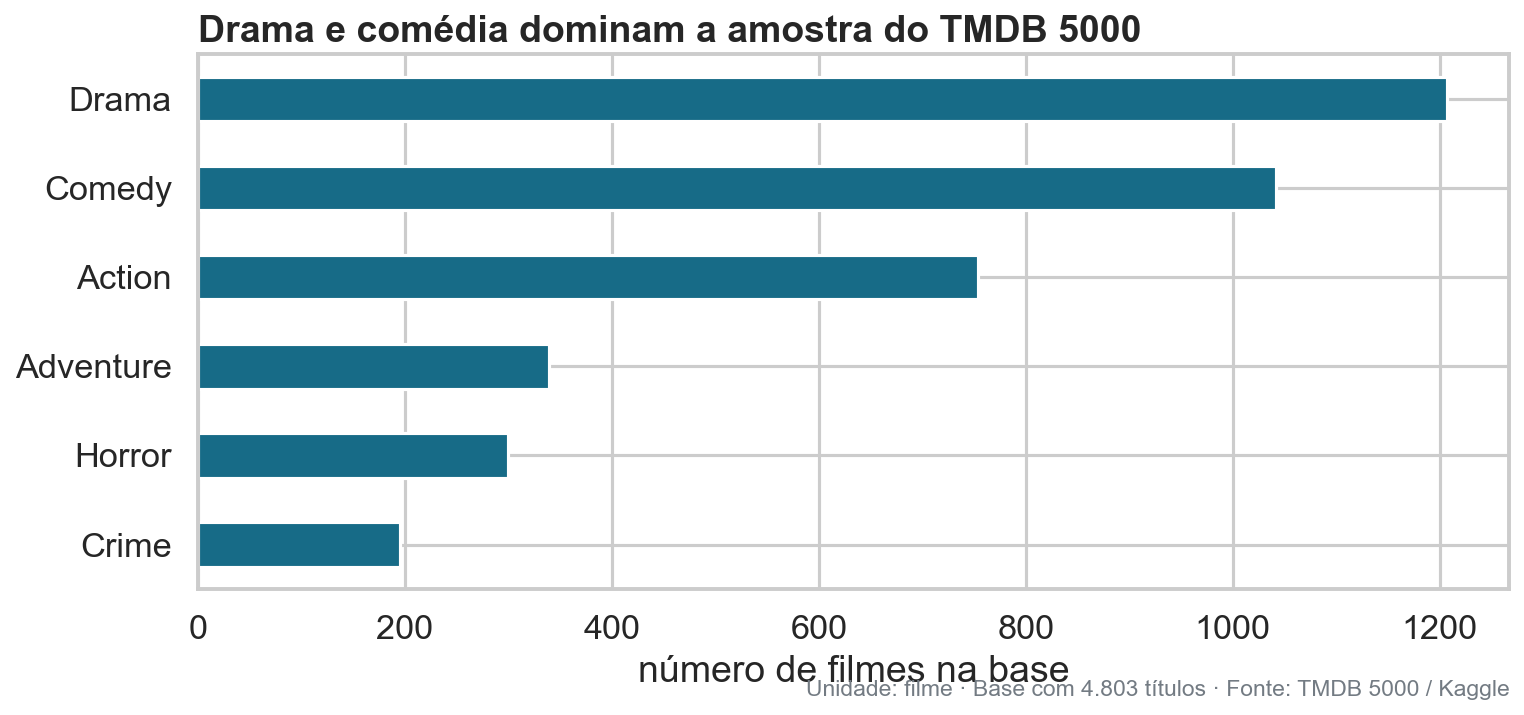

Remover grades, bordas e cores desnecessárias reduz ruído. Remover
unidade, população, fonte ou filtros elimina informação necessária para
interpretar o resultado. Um gráfico simples não é um gráfico sem
contexto.

### Anotação e identificação direta

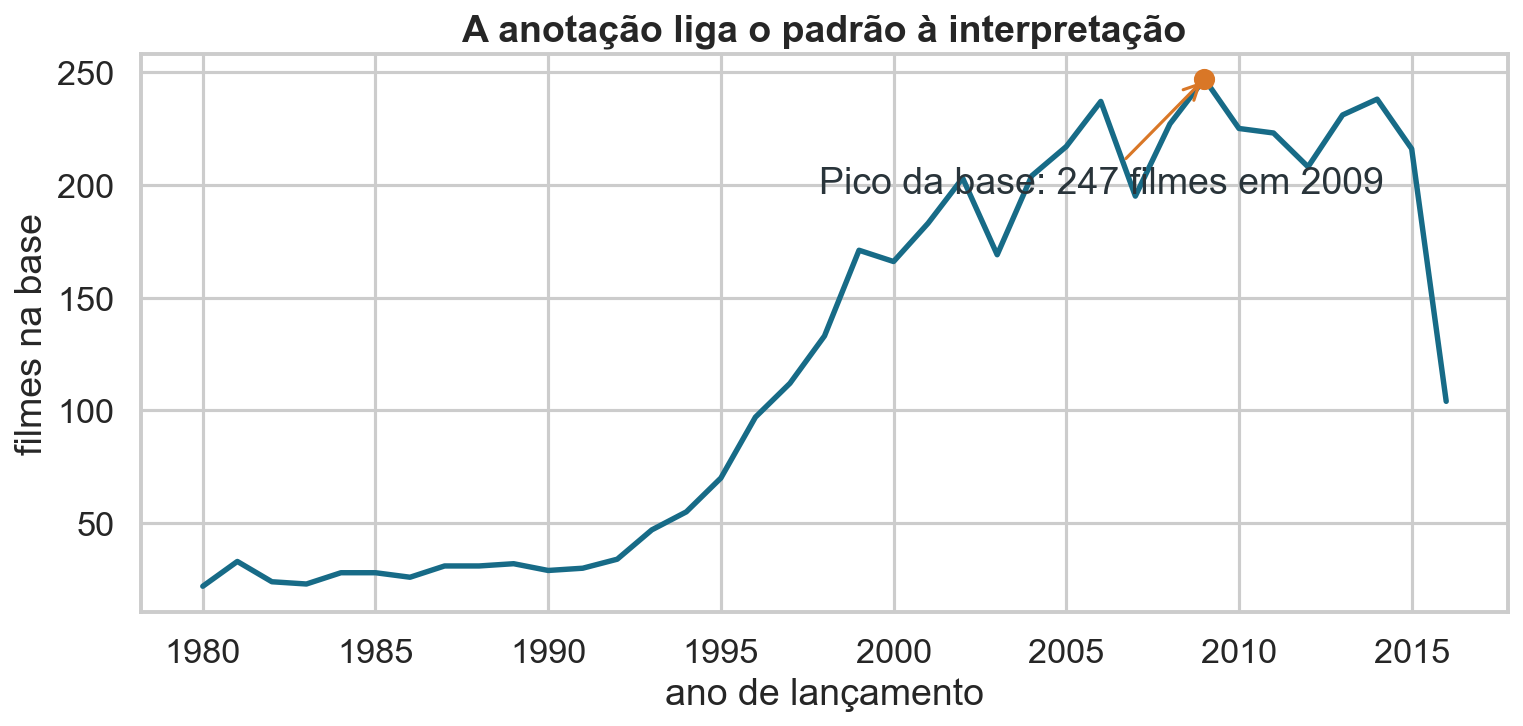

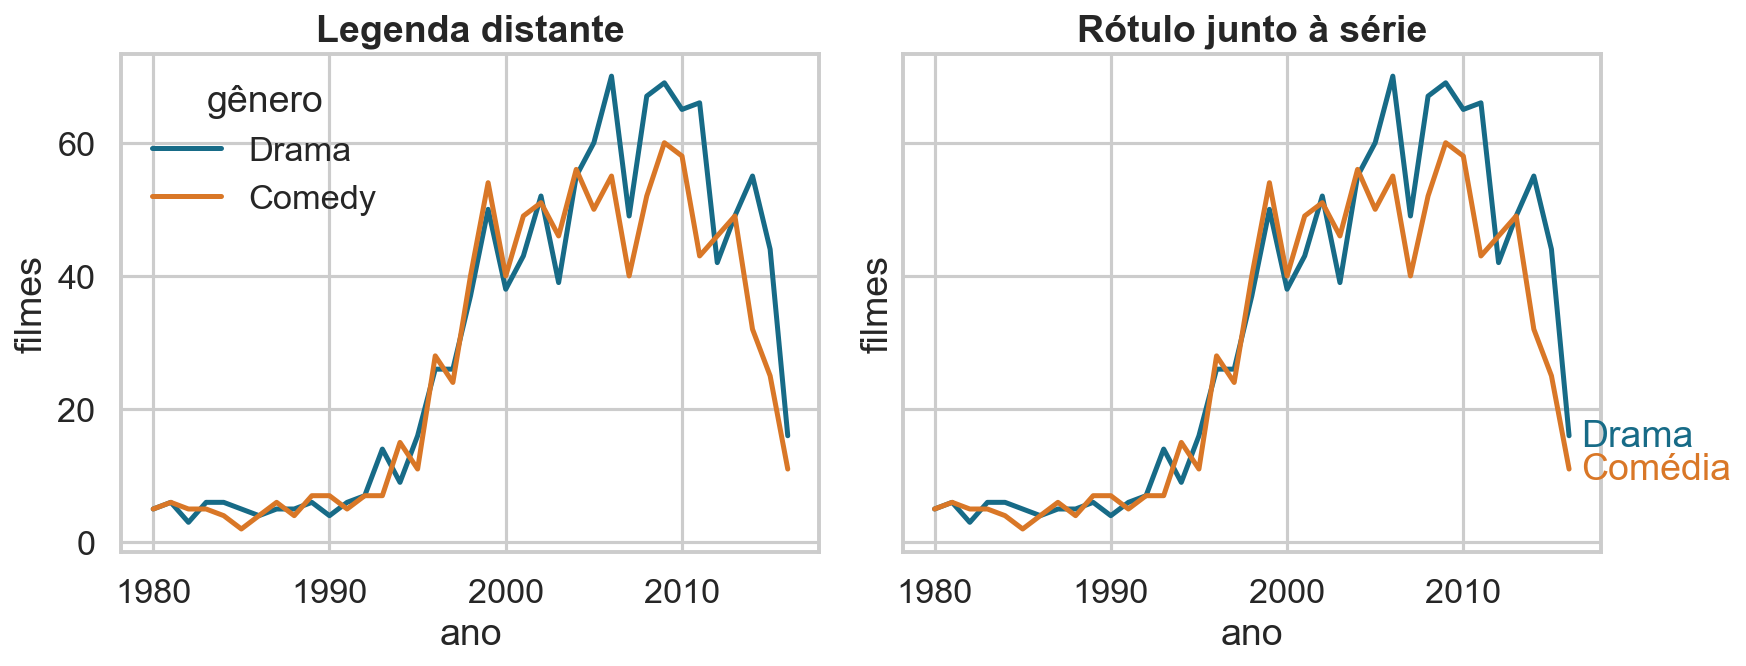

Uma anotação deve aproximar evidência e interpretação. Rótulos diretos
reduzem o esforço de procurar a cor na legenda e voltar ao gráfico;
anotar todos os pontos produziria o efeito contrário.

### Formato e sobreposição também mudam a leitura

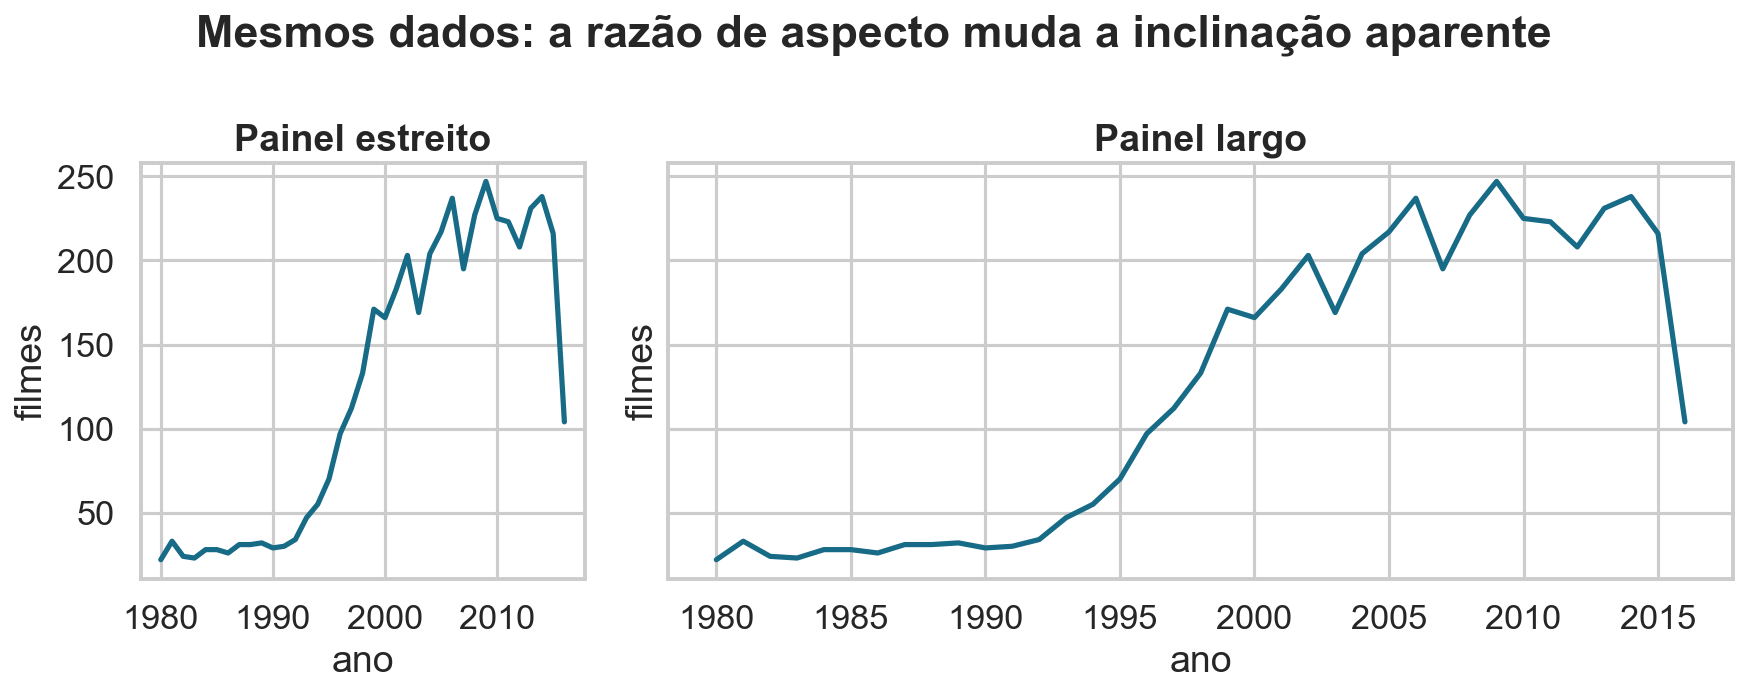

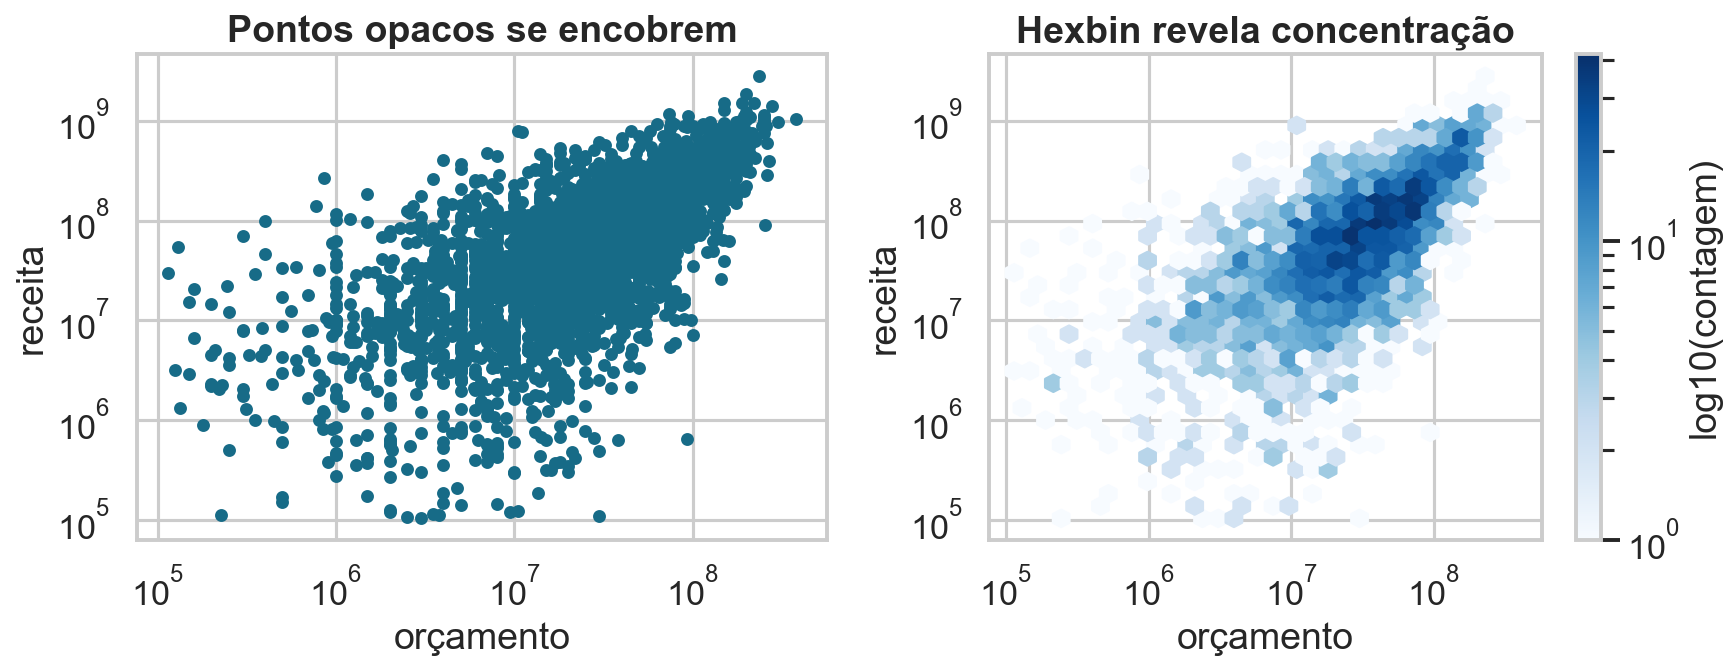

A razão de aspecto altera a inclinação aparente sem alterar nenhum dado.
Em dispersões densas, pontos opacos encobrem uns aos outros;
transparência preserva observações individuais, enquanto `hexbin`
responde melhor à pergunta sobre concentração local.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(valid["budget"], valid["revenue"], alpha=.15, s=12)
axes[1].hexbin(valid["budget"], valid["revenue"], gridsize=32,
               mincnt=1, bins="log", cmap="Blues",
               xscale="log", yscale="log")
axes[0].set(xscale="log", yscale="log")
for ax in axes:
    ax.set(xlabel="orçamento", ylabel="receita")
plt.tight_layout(); plt.show()

### Agregação e acessibilidade

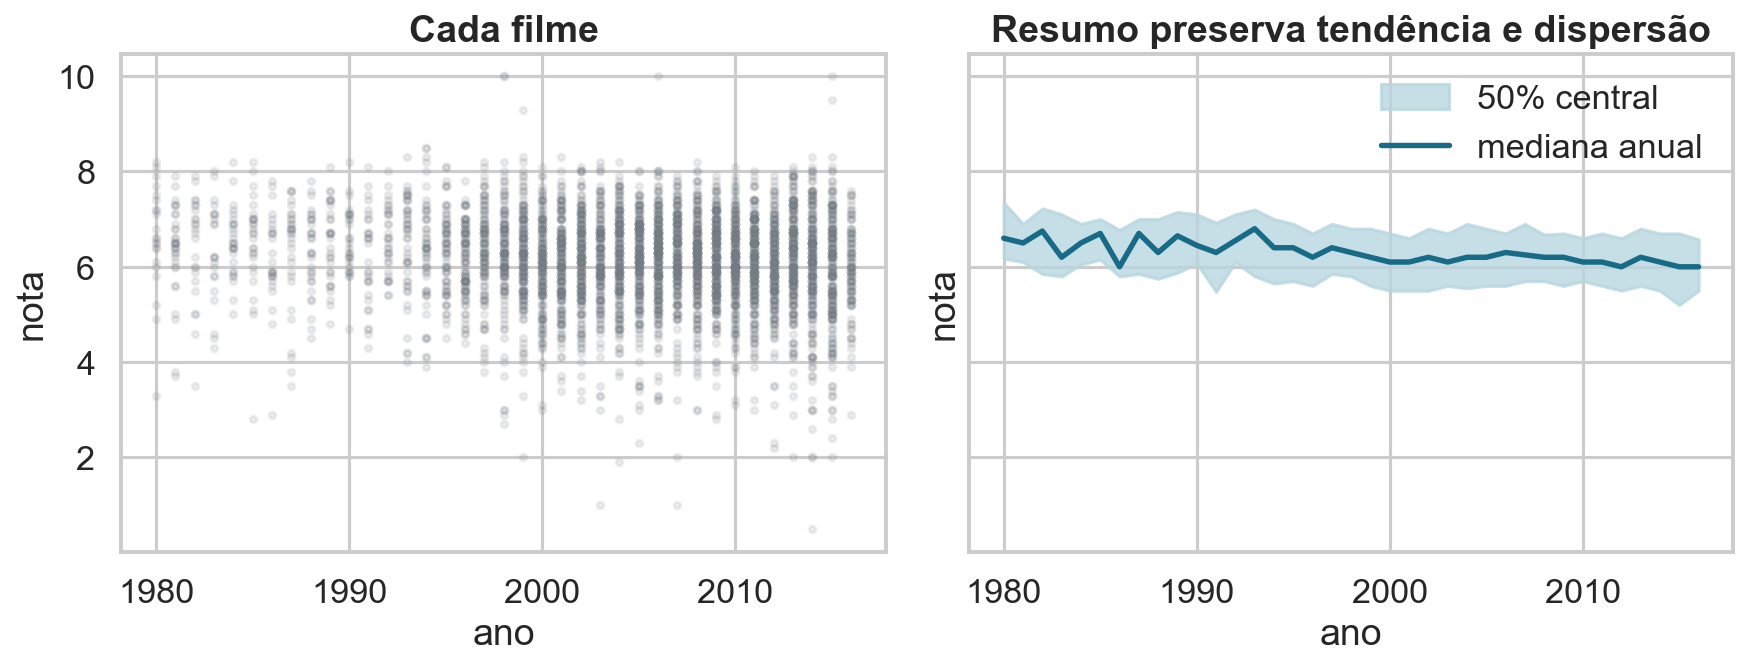

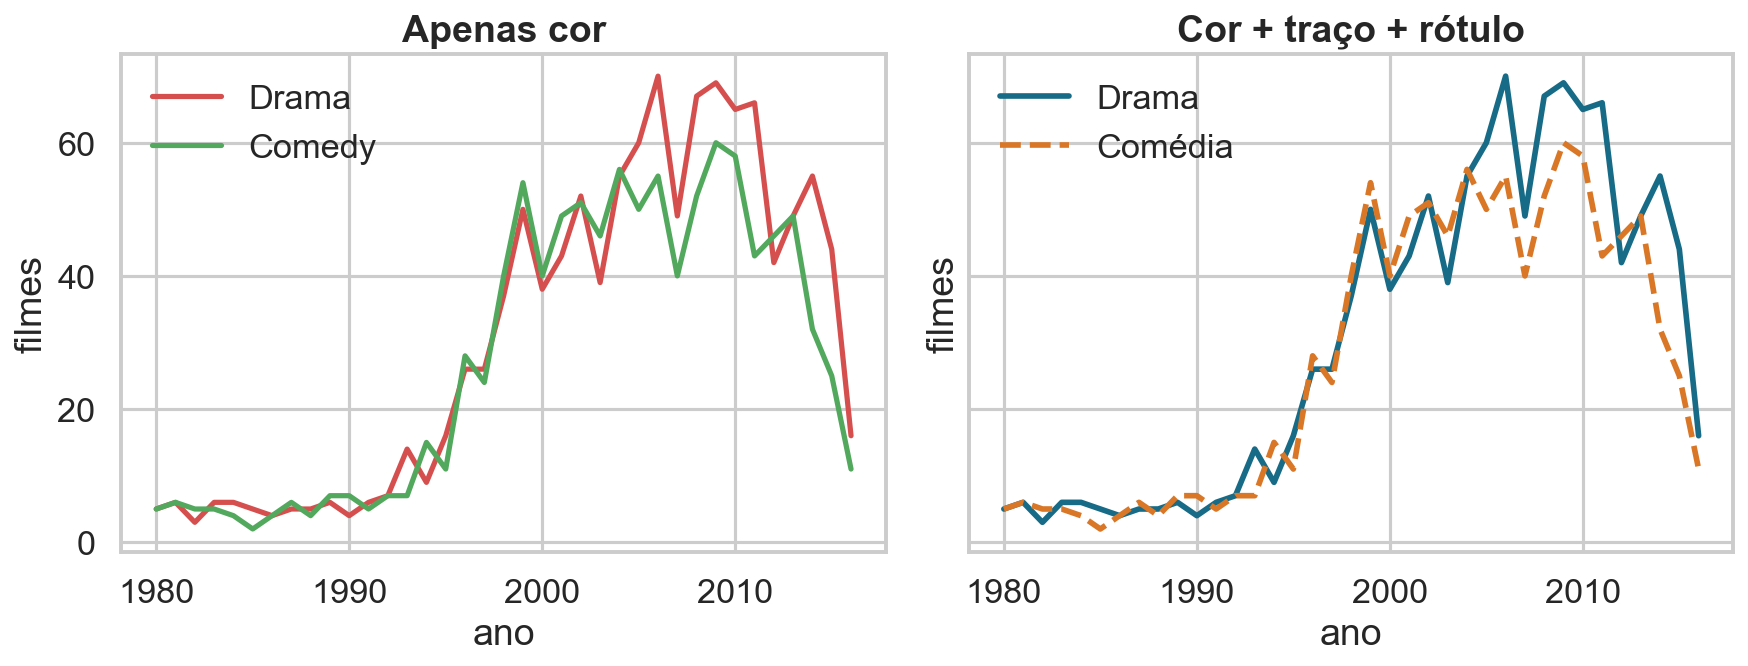

Agregar pode reduzir milhares de marcas a uma tendência legível, mas o
resumo deve preservar a variação relevante — aqui, mediana e intervalo
interquartil aparecem juntos. Para acessibilidade, a categoria não deve
depender apenas da percepção de cor: tipo de linha, forma ou rótulo
fornecem canais redundantes.

## Auditoria de um gráfico

Use a função abaixo como checklist textual antes de publicar.

In [ ]:
def auditar_grafico(pergunta, unidade, periodo, filtros, mensagem):
    return pd.Series({
        "pergunta": pergunta,
        "unidade de observação": unidade,
        "período": periodo,
        "filtros": filtros,
        "mensagem verificável": mensagem,
    })

auditar_grafico(
    "Como orçamento e receita se relacionam?",
    "filme",
    "datas presentes na base TMDB 5000",
    "orçamento e receita > US$ 100 mil",
    "A relação positiva aparece melhor em escala log-log",
)

## Desafio final

Escolha uma pergunta sobre gênero, tempo ou finanças. Produza duas
versões:

1.  uma versão deliberadamente ruim;
2.  uma versão revisada com comparação, escala, contexto e destaque
    coerentes.

Escreva três frases justificando cada mudança.

## Para guardar

Boas práticas não são uma lista de proibições. Elas derivam da tarefa
perceptiva, da pergunta e do compromisso de representar dados com
transparência.

# Guia teórico consolidado

## Escala é parte do argumento

Barras codificam magnitude pelo comprimento desde uma origem comum; por
isso, truncar o zero exagera razões. Pontos e linhas podem usar domínios
locais quando a pergunta é variação, desde que a escala seja explícita.
Dois eixos verticais são particularmente perigosos: domínios e
orientação independentes permitem fabricar concordância ou oposição
entre curvas.

A escala logarítmica transforma razões em distâncias:

$$\log(ab)=\log(a)+\log(b).$$

Ela é apropriada para fenômenos multiplicativos e caudas longas, mas
exige valores positivos, marcas interpretáveis e indicação clara da
transformação.

## Tempo, comparação e condicionamento

Linhas sugerem continuidade e só devem conectar valores com ordem
significativa. Comparações entre painéis pedem domínios comuns.
Condicionar por grupo, espaço ou tempo permite enxergar heterogeneidade
sem misturar populações distintas. Contagens absolutas e razões
respondem perguntas diferentes: volume não é composição.

## Cor, destaque e acessibilidade

Paletas qualitativas separam categorias; sequenciais representam
magnitude ordenada; divergentes exigem um centro substantivo. Luminância
deve acompanhar a ordem. Vermelho e verde não bastam para parte do
público; cor precisa ser combinada com posição, forma, rótulo ou
contraste.

Destaque cria hierarquia: poucas cores fortes e cinza para contexto
geralmente comunicam melhor que uma paleta saturada. Legendas distantes
aumentam o esforço; rótulos diretos aproximam evidência e interpretação.

## Incerteza e ética

Médias sem distribuição ou incerteza podem sugerir precisão inexistente.
Razão de aspecto, filtragem, domínio dos eixos e omissão de grupos
alteram a interpretação. Um gráfico correto também declara unidade,
período, filtros, fonte, limitações e a mensagem verificável que
sustenta.